# Polytomous IRT Models

This notebook demonstrates the polytomous IRT models supported by the library:
- **PCM** (Partial Credit Model) - Rasch-like for ordered categories
- **RSM** (Rating Scale Model) - Same rating scale across items
- **GRM** (Graded Response Model) - Cumulative probability model
- **GPCM** (Generalized Partial Credit Model) - PCM with discrimination
- **NRM** (Nominal Response Model) - For unordered categories

Use polytomous models when your data has Likert scales, partial credit, or multiple-choice items with more than two response options.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from irt import fit

np.random.seed(42)

## 1. Data Preparation

Polytomous data: integer responses 0, 1, 2, ..., m-1 per item. Missing = NaN.

In [2]:
# Simulate Likert-scale data: 200 persons, 8 items, 5 categories (0-4)
X = np.random.randint(0, 5, size=(200, 8)).astype(float)
# Add some missing
mask_miss = np.random.random(X.shape) < 0.05
X[mask_miss] = np.nan

print("Shape:", X.shape)
print("Categories per item (inferred):", np.nanmax(X, axis=0).astype(int) + 1)

Shape: (200, 8)
Categories per item (inferred): [5 5 5 5 5 5 5 5]


## 2. Model Fitting

Fit each polytomous model with `fit(X, model="pcm")` etc.

In [3]:
result_pcm = fit(X, model="pcm")
print("PCM:", result_pcm.converged, "loglik =", result_pcm.loglik)

result_gpcm = fit(X, model="gpcm")
print("GPCM:", result_gpcm.converged, "loglik =", result_gpcm.loglik)

result_grm = fit(X, model="grm")
print("GRM:", result_grm.converged, "loglik =", result_grm.loglik)

PCM: True loglik = -2597.289006747975
GPCM: True loglik = -2446.657358427635
GRM: True loglik = -2430.3056376142385


## 3. Parameter Interpretation

Each model has different parameter structures. Use `item_report()` and `params`.

In [4]:
print("PCM params:", result_pcm.params.keys())
print("PCM b (step params) shape:", result_pcm.params["b"].shape)
print(result_pcm.item_report().head())

PCM params: dict_keys(['b'])
PCM b (step params) shape: (8, 4)
     item  n_obs    b_mean
0  item_0    188  0.067745
1  item_1    189 -0.031616
2  item_2    185 -0.036429
3  item_3    190 -0.035296
4  item_4    190  0.055839


## 4. Scoring

EAP, MAP, and MLE for polytomous models.

In [5]:
scores_eap = result_pcm.score(method="eap")
scores_map = result_pcm.score(method="map")
print("EAP theta[:5]:", scores_eap.theta[:5])
print("EAP SE[:5]:", scores_eap.se[:5])

EAP theta[:5]: [ 0.39971265  0.16287202  0.08606265  0.15122708 -0.00744311]
EAP SE[:5]: [0.29813379 0.28169776 0.27945296 0.28029551 0.27950887]


## 5. Category Characteristic Curves

Plot P(X=c|theta) vs theta for each category.

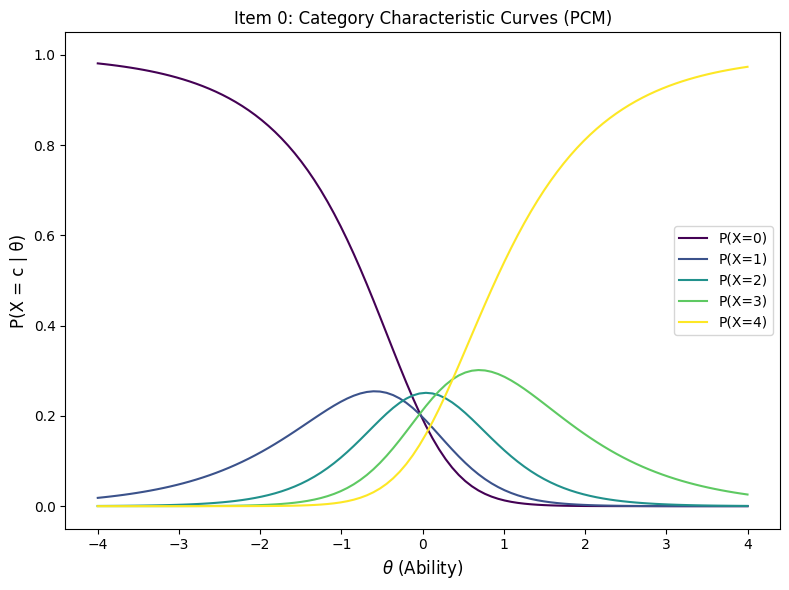

In [6]:
fig, ax = result_pcm.plot_icc(items=[0])
ax.set_title("Item 0: Category Characteristic Curves (PCM)")
plt.tight_layout()
plt.show()

## 6. Model Comparison

Compare AIC/BIC across models.

In [7]:
for model_name, res in [("PCM", result_pcm), ("GPCM", result_gpcm), ("GRM", result_grm)]:
    mf = res.model_fit()
    print(f"{model_name}: AIC={mf['aic']:.1f}, BIC={mf['bic']:.1f}")

PCM: AIC=5258.6, BIC=5364.1
GPCM: AIC=4973.3, BIC=5105.2
GRM: AIC=4940.6, BIC=5072.5


## 7. Diagnostics

Item fit, person fit, and model fit for polytomous.

In [8]:
item_fit = result_pcm.item_fit()
print(item_fit[['item', 'n_obs', 'infit_ms', 'outfit_ms']].head())

person_fit = result_pcm.person_fit()
print(person_fit[['person', 'theta', 'infit_ms']].head())

     item  n_obs  infit_ms  outfit_ms
0  item_0    188  1.024824   1.011444
1  item_1    189  1.070153   1.091238
2  item_2    185  1.066557   1.071865
3  item_3    190  0.967944   0.968346
4  item_4    190  1.023472   1.021246
     person     theta  infit_ms
0  person_0  0.399713  0.831227
1  person_1  0.162872  0.584959
2  person_2  0.086063  1.439443
3  person_3  0.151227  0.330524
4  person_4 -0.007443  1.423340


## 8. RSM and NRM

RSM assumes the same rating scale across items. NRM is for nominal (unordered) categories.

In [9]:
result_rsm = fit(X, model="rsm")
print("RSM converged:", result_rsm.converged)
print("RSM tau (common steps):", result_rsm.params["tau"])

result_nrm = fit(X, model="nrm")
print("NRM converged:", result_nrm.converged)

RSM converged: True
RSM tau (common steps): [-0.13017083 -0.11011949  0.09084542  0.1494449 ]
NRM converged: False


/Users/paulius.satkus/Documents/Item Response Theory Python/irt/api.py:262: RuntimeWarning: MML-EM (polytomous) did not converge in 200 iterations.
  result = fit_mml_em_poly(
